# ID Duplication Check

This notebook checks duplicate IDs in `transaction.csv`.

It reports:
- duplicate ID count
- duplicate ID percentage
- repeated ID values with frequency
- full rows where ID is duplicated

In [7]:
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

df = pd.read_csv("transaction.csv")
print(f"Loaded dataframe shape: {df.shape}")
print("Columns:", list(df.columns))

Loaded dataframe shape: (10103, 6)
Columns: ['status', 'time', 'card_type', 'city', 'amount', 'id']


## Select ID Column

In [8]:
# Change this to your ID column name if needed.
# Examples: "Transaction ID", "transaction_id", "id"
ID_COLUMN = "id"

if ID_COLUMN not in df.columns:
    id_like_cols = [c for c in df.columns if "id" in str(c).lower()]
    raise ValueError(
        f"ID column '{ID_COLUMN}' not found. ID-like columns found: {id_like_cols}"
    )

print(f"Using ID column: {ID_COLUMN}")

Using ID column: id


## Duplicate ID Summary

In [9]:
id_series = df[ID_COLUMN].astype("string").str.strip()
null_mask = id_series.isna() | (id_series == "")
non_null_ids = id_series[~null_mask]

dup_mask_non_null = non_null_ids.duplicated(keep=False)
duplicate_id_rows = int(dup_mask_non_null.sum())
total_non_null_id_rows = int((~null_mask).sum())
duplicate_id_pct = round((duplicate_id_rows / total_non_null_id_rows) * 100, 2) if total_non_null_id_rows else 0.0

summary = pd.DataFrame([
    {"metric": "Total rows", "value": len(df)},
    {"metric": "Rows with null/blank ID", "value": int(null_mask.sum())},
    {"metric": "Rows with non-null ID", "value": total_non_null_id_rows},
    {"metric": "Rows with duplicated ID", "value": duplicate_id_rows},
    {"metric": "Duplicate ID rate (%) over non-null IDs", "value": duplicate_id_pct},
])

display(summary)

,metric,value
0,Total rows,10103.0
1,Rows with null/blank ID,0.0
2,Rows with non-null ID,10103.0
3,Rows with duplicated ID,10103.0
4,Duplicate ID rate (%) over non-null IDs,100.0


## Repeated ID Values and Frequency

In [10]:
# Show only duplicated ID and its duplicate count
repeated_ids = (
    non_null_ids.value_counts()
    .loc[lambda s: s > 1]
    .rename_axis(ID_COLUMN)
    .reset_index(name="duplicate_count")
    .sort_values(by=["duplicate_count", ID_COLUMN], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Duplicated unique ID values: {len(repeated_ids)}")
display(repeated_ids)

Duplicated unique ID values: 99


,id,duplicate_count
0,54,124
1,74,122
2,89,122
3,10,121
4,52,121
...,...,...
94,80,88
95,32,87
96,27,86
97,20,85


## Exact Duplicate Row Check

Checks whether any full rows (all columns) are duplicated.

In [11]:
# Exact duplicate rows across all columns
# keep=False marks all occurrences within duplicate groups

dup_row_mask = df.duplicated(keep=False)
exact_dup_rows = df[dup_row_mask].copy()

# Group identical rows and count repeats
if len(exact_dup_rows) > 0:
    dup_row_groups = (
        exact_dup_rows
        .groupby(list(df.columns), dropna=False)
        .size()
        .reset_index(name="duplicate_count")
        .sort_values(by="duplicate_count", ascending=False)
        .reset_index(drop=True)
    )
else:
    dup_row_groups = pd.DataFrame(columns=list(df.columns) + ["duplicate_count"])

summary_exact_dup = pd.DataFrame([
    {"metric": "Total rows", "value": len(df)},
    {"metric": "Rows that are part of exact duplicate groups", "value": int(dup_row_mask.sum())},
    {"metric": "Unique exact duplicate row patterns", "value": len(dup_row_groups)},
])

print("Exact duplicate row summary:")
display(summary_exact_dup)

print("Exact duplicate row patterns (top 100):")
display(dup_row_groups.head(100))

print("Rows that are exact duplicates (top 200):")
display(exact_dup_rows.head(200))

Exact duplicate row summary:


,metric,value
0,Total rows,10103
1,Rows that are part of exact duplicate groups,0
2,Unique exact duplicate row patterns,0


Exact duplicate row patterns (top 100):


,status,time,card_type,city,amount,id,duplicate_count


Rows that are exact duplicates (top 200):


,status,time,card_type,city,amount,id


## Duplication Visualizations

Charts for duplicate-record analysis (rows with duplicated IDs, unique vs duplicated IDs, and top duplicated ID values).

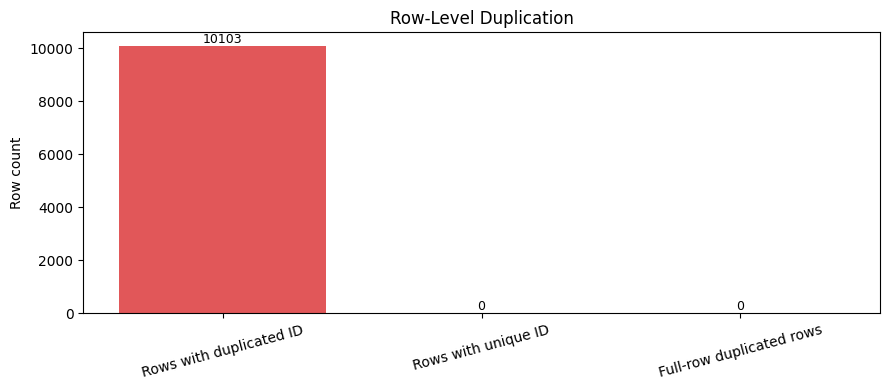

In [15]:
# Visualization prep + Chart 1 (Row-Level Duplication)
import matplotlib.pyplot as plt

id_series = df[ID_COLUMN].astype("string").str.strip()
null_mask = id_series.isna() | (id_series == "")
non_null_ids = id_series[~null_mask]

# ID-duplication masks
_dup_mask = non_null_ids.duplicated(keep=False)
rows_with_dup_id = int(_dup_mask.sum())
rows_without_dup_id = int((~_dup_mask).sum())

# Full-row duplication across all columns
full_row_dup_count = int(df.duplicated(keep=False).sum())

id_counts = non_null_ids.value_counts()
dup_id_counts = id_counts[id_counts > 1]
unique_id_count = int((id_counts == 1).sum())
duplicated_id_count = int((id_counts > 1).sum())

top_n = 15
top_dup = dup_id_counts.head(top_n)

labels = ["Rows with duplicated ID", "Rows with unique ID", "Full-row duplicated rows"]
values = [rows_with_dup_id, rows_without_dup_id, full_row_dup_count]
colors = ["#e15759", "#4e79a7", "#f28e2b"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, values, color=colors)
ax.set_title("Row-Level Duplication")
ax.set_ylabel("Row count")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(values):
    ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

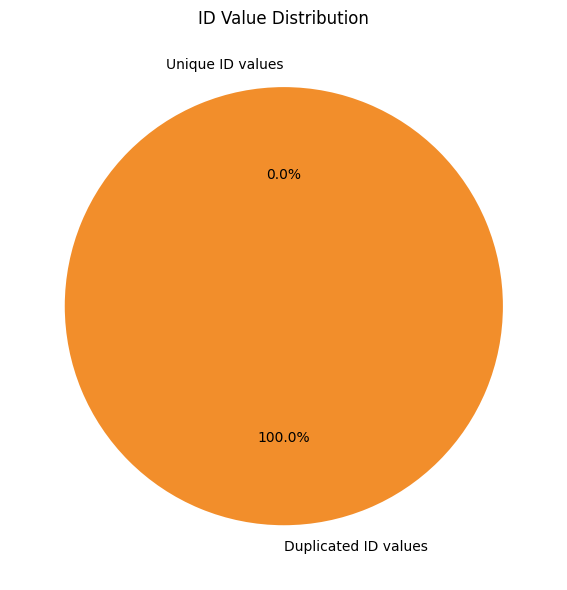

In [13]:
# Chart 2 (ID Value Distribution)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [unique_id_count, duplicated_id_count],
    labels=["Unique ID values", "Duplicated ID values"],
    autopct="%1.1f%%",
    colors=["#59a14f", "#f28e2b"],
    startangle=90,
)
ax.set_title("ID Value Distribution")
plt.tight_layout()
plt.show()

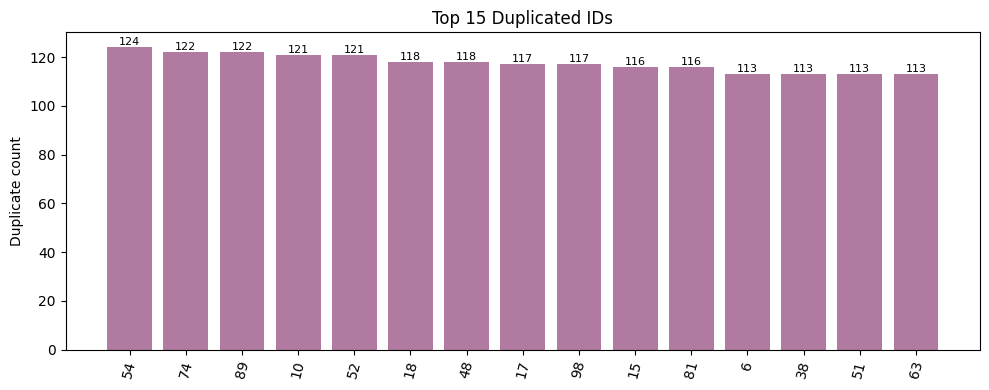

In [16]:
# Chart 3 (Top Duplicated IDs)
fig, ax = plt.subplots(figsize=(10, 4))
if len(top_dup) > 0:
    bars = ax.bar(top_dup.index.astype(str), top_dup.values, color="#b07aa1")
    ax.set_title(f"Top {min(top_n, len(top_dup))} Duplicated IDs")
    ax.set_ylabel("Duplicate count")
    ax.tick_params(axis="x", rotation=75)

    # Add duplication count labels above bars
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
else:
    ax.text(0.5, 0.5, "No duplicated IDs", ha="center", va="center", fontsize=12)
    ax.set_title("Top Duplicated IDs")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()